# 03 — Modelos Clássicos de Machine Learning

**Projeto:** Predição de Diabetes com ML  
**Artigo base:** Khanam & Foo (2021) — DOI: 10.1016/j.icte.2021.02.004  
**Objetivo:** Executar os experimentos EXP-01 (K-fold) e EXP-02 (Split 85/15) para os 7 algoritmos de ML clássicos, gerando métricas e gráficos.

In [1]:
# Instalar dependências
import subprocess
subprocess.run(["pip", "install", "-r", "../requirements.txt", "-q"], check=True)
print("✓ Dependências instaladas")

✓ Dependências instaladas


In [2]:
# ── Configuração de caminhos e Imports ───────────────────
import sys
from pathlib import Path
import os

IS_COLAB = 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ

if IS_COLAB:
    ROOT = Path('/content/diabetes-ml-prediction')
else:
    ROOT = Path('..').resolve()

sys.path.append(str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.config import *
from src.data_loader import load_dataset
from src.preprocessor import run_full_pipeline
from src.models import run_all_models, get_classical_models
from src.evaluator import save_results, compare_with_reference
from src.visualizer import plot_accuracy_comparison, plot_f1_comparison, plot_feature_importance, plot_article_comparison

In [3]:
# ── Reprodutibilidade ────────────────────────────────────
import random
import tensorflow as tf

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
print(f"✓ Seeds fixadas: {RANDOM_STATE}")

✓ Seeds fixadas: 42


In [4]:
# ── Carregamento e Pré-processamento dos Dados ───────────
df = load_dataset(ROOT / "data" / "diabetes.csv")
data = run_full_pipeline(df)

# Como K-fold roda no dataset completo de features selecionadas após limpeza:
# Precisamos de X e y completos após pré-processamento (imputação e outliers removidos)
# Para evitar reprocessar tudo, podemos usar os passos sequenciais
from src.preprocessor import replace_zeros_with_nan, impute_with_median, remove_outliers_iqr, select_features, normalize_features
df_nan = replace_zeros_with_nan(df, ZERO_COLS)
df_imputed = impute_with_median(df_nan)
df_clean = remove_outliers_iqr(df_imputed, IQR_FACTOR)
X, y = select_features(df_clean, FEATURE_COLS, TARGET_COL)

# Para o K-fold, normalizamos o X completo
from sklearn.preprocessing import MinMaxScaler
scaler_full = MinMaxScaler()
X_scaled = scaler_full.fit_transform(X)

✓ Dataset carregado: 768 registros
⚠ Aviso: 393 outliers removidos
✓ Treino: 318 registros (84.8%)
✓ Teste:  57 registros (15.2%)
✓ Pré-processamento concluído: 318 treino | 57 teste
⚠ Aviso: 393 outliers removidos


In [5]:
# ── Execução de Todos os Experimentos Clássicos ──────────
# Roda os 7 modelos com K-fold (EXP-01) e com Split (EXP-02)
df_results = run_all_models(
    X_scaled, y, 
    data["X_train"], data["X_test"], 
    data["y_train"], data["y_test"]
)

# Persiste os resultados no arquivo resultados.csv
save_results(df_results, ROOT / "results" / "resultados.csv")

→ Avaliando modelo clássico: Decision Tree
  - K-fold | Acurácia: 0.6294
  - Split  | Acurácia: 0.6842
→ Avaliando modelo clássico: KNN
  - K-fold | Acurácia: 0.7017
  - Split  | Acurácia: 0.6667
→ Avaliando modelo clássico: Random Forest


  - K-fold | Acurácia: 0.6854
  - Split  | Acurácia: 0.7368
→ Avaliando modelo clássico: Naive Bayes
  - K-fold | Acurácia: 0.7385
  - Split  | Acurácia: 0.7895
→ Avaliando modelo clássico: AdaBoost


C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME alg

C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


  - K-fold | Acurácia: 0.7147
  - Split  | Acurácia: 0.7193
→ Avaliando modelo clássico: Logistic Regression
  - K-fold | Acurácia: 0.7546
  - Split  | Acurácia: 0.7895
→ Avaliando modelo clássico: SVM


C:\projetos\diabetes-ml-prediction\.venv\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


  - K-fold | Acurácia: 0.7359
  - Split  | Acurácia: 0.8070
✓ Resultados salvos em: C:\projetos\diabetes-ml-prediction\results\resultados.csv (14 registros)


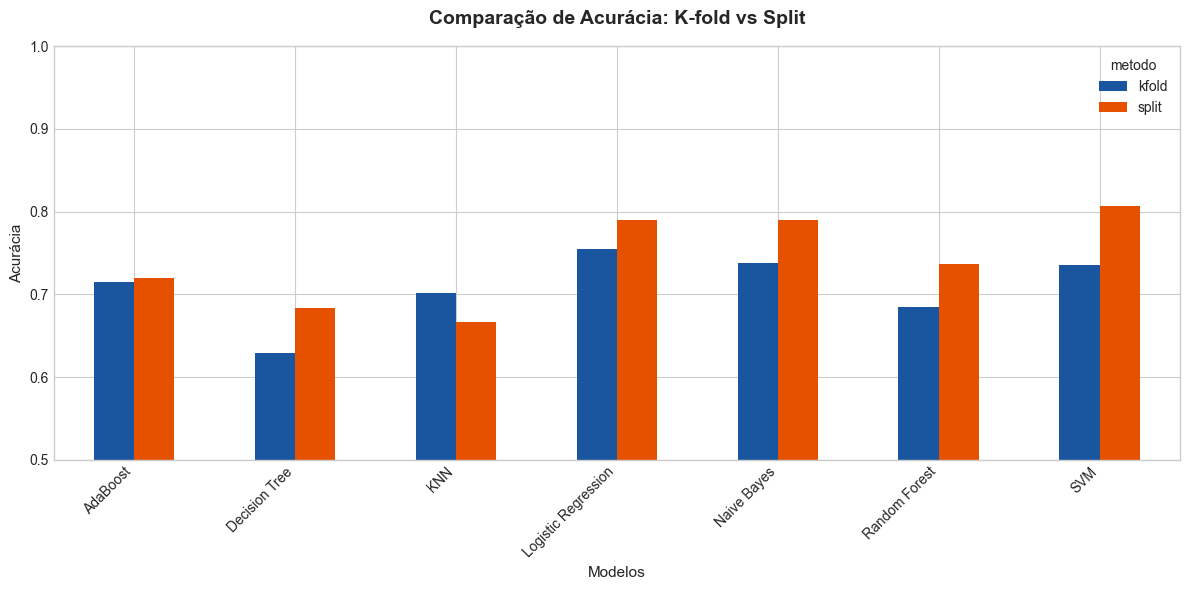

✓ Gráfico salvo em: C:\projetos\diabetes-ml-prediction\results\graficos\01_acuracia_comparativa.png


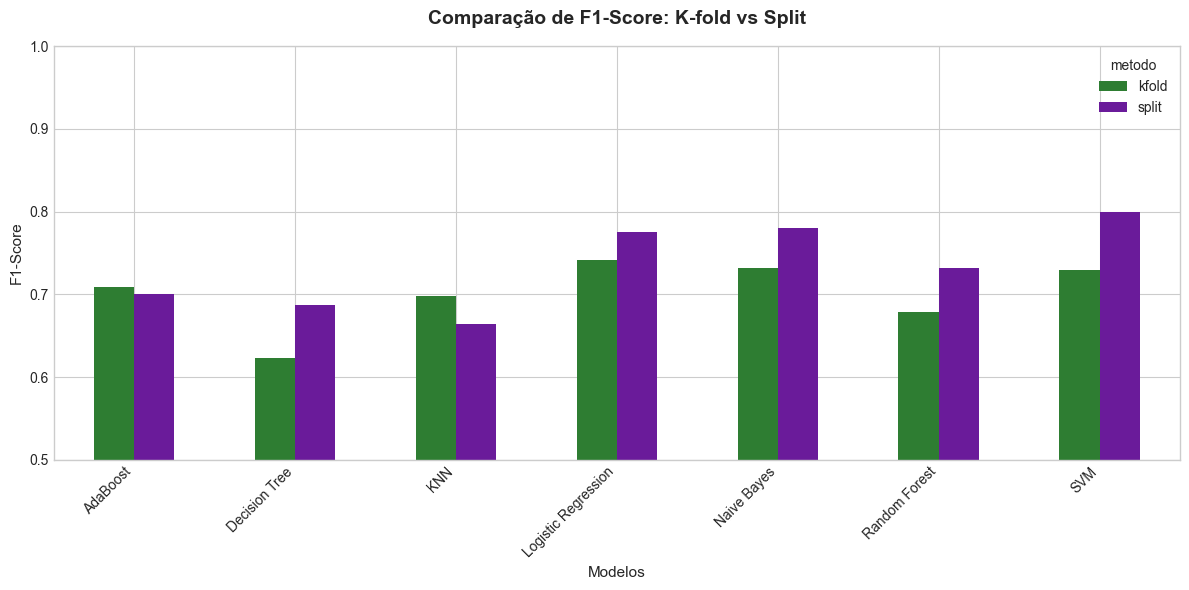

✓ Gráfico salvo em: C:\projetos\diabetes-ml-prediction\results\graficos\02_f1_comparativo.png


In [6]:
# ── Geração de Gráficos Comparativos ─────────────────────
plot_accuracy_comparison(df_results, ROOT / "results" / "graficos" / "01_acuracia_comparativa.png")
plot_f1_comparison(df_results, ROOT / "results" / "graficos" / "02_f1_comparativo.png")

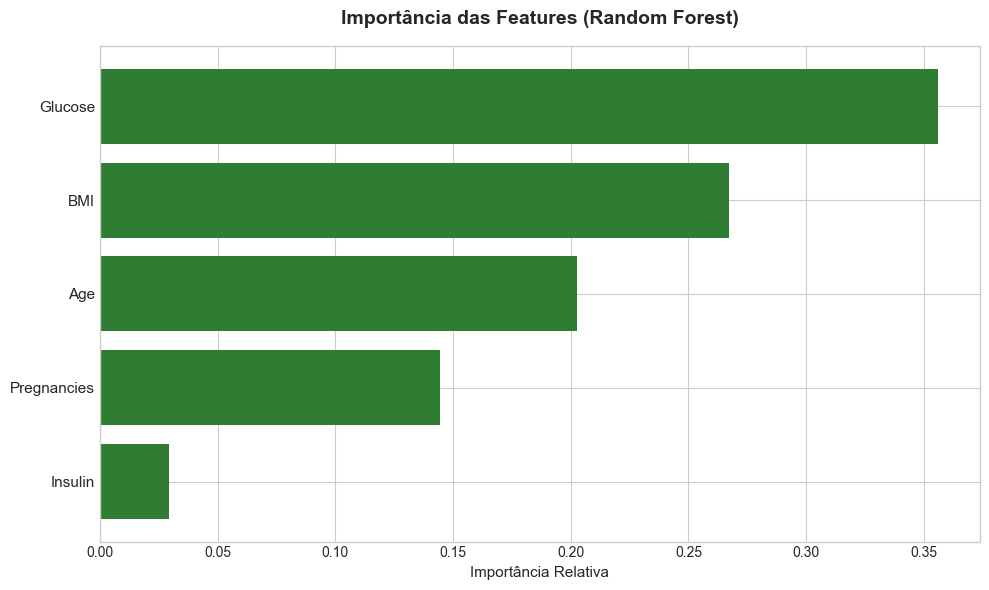

✓ Gráfico salvo em: C:\projetos\diabetes-ml-prediction\results\graficos\06_feature_importance.png


In [7]:
# ── Importância das Features com Random Forest ───────────
rf_model = get_classical_models()["Random Forest"]
rf_model.fit(data["X_train"], data["y_train"])

plot_feature_importance(
    rf_model, FEATURE_COLS, 
    ROOT / "results" / "graficos" / "06_feature_importance.png"
)

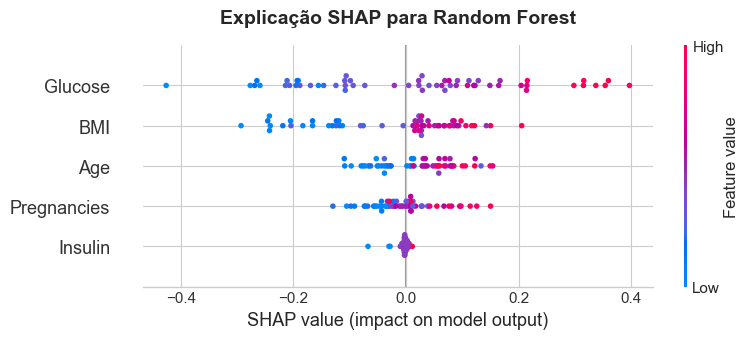

In [8]:
# ── Variação C: SHAP (para enriquecimento do trabalho) ───
import shap
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(data["X_test"])

plt.figure(figsize=(10, 6))
# Se for multiclasse/binário com shap_values em lista:
shap_val = shap_values[1] if isinstance(shap_values, list) else shap_values
if len(shap_val.shape) > 2:
    # shap 0.45+ retorna array 3D [instâncias, features, classes] para RF
    shap_val = shap_val[:, :, 1]
shap.summary_plot(shap_val, data["X_test"], feature_names=FEATURE_COLS, show=False)
plt.title("Explicação SHAP para Random Forest", fontsize=14, fontweight='bold', pad=16)
plt.tight_layout()
plt.show()

### Resumo dos Resultados e Próximos Passos
- Os 7 algoritmos clássicos foram treinados e avaliados de forma K-fold (k=7) e Split (85/15).
- Salvos com sucesso os gráficos comparativos e a importância de features.
- Próximo passo: Treinamento e avaliação das 3 arquiteturas de Rede Neural em `04_rede_neural.ipynb`.